# Анализ лояльности пользователей Яндекс Афиши

Автор: Мусалаев Богдан

Дата: 18.07.26-21.07.26

### Цели и задачи проекта

Цели:
- Провести анализ лояльности пользователей Яндекс Афиши для помощи команде маркетинга в понимании поведения пользователей для:
    - Выявления перспективных клиентов;
    - Точной настройки таргетной рекламы;
    - Оптимизации маркетинговых бюджетов;
    - Повышения удержания клиентов.
В рамках проекта лояльность определяем по возвращаемости пользователей: "вернувшийся" пользователь >=2 заказов, "лояльный" пользователь >=5 заказов      

Задачи:
- Загрузить данные и ознакомиться с ними;
- Подготовить данные к EDA;
- Создать профиль пользователя;
- Провести исследовательский анализ данных;
- Сформулировать выводы и рекомендации основываясь на проведенном EDA.


### Описание данных
Выгрузка из базы данных SQL (таблицы afisha.purchases, afisha.events, afisha.city, afisha.regions) отфильтрованная по пользователям mobile и desktop и без типа мероприятия "фильм" позволила собрать следующие данные:

- user_id — уникальный идентификатор пользователя, совершившего заказ;
- device_type_canonical — тип устройства, с которого был оформлен заказ;
- order_id — уникальный идентификатор заказа;
- order_dt — дата создания заказа;
- order_ts — дата и время создания заказа;
- currency_code — валюта оплаты;
- revenue — выручка от заказа;
- tickets_count — количество купленных билетов;
- days_since_prev — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- event_id — уникальный идентификатор мероприятия;
- event_name - название мероприятия(пропущено в описании задания на Практикуме);
- service_name — название билетного оператора;
- event_type_main — основной тип мероприятия (театральная постановка, концерт и так далее);
- region_name — название региона, в котором прошло мероприятие;
- city_name — название города, в котором прошло мероприятие.

Так же будет использованы данные final_tickets_tenge_df.csv где указан курс за 100 тенге.


### Содержимое проекта

- [1. Загрузка данных и предобработка](#step1)
- [2. Предобработка данных](#step2)
- [3. Создание профиля пользователя](#step3)
- [4. Исследовательский анализ данных](#step4)
- [5. Общий вывод и рекомендации](#step5)
- [6. Финализация проекта](#step6)

<a id='step1'></a>
## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

(УДАЛЕНО ДЛЯ ЗАЛИВАНИЯ НА GITHUB)

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` - название мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Импортируем нужные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import sqlalchemy
from sqlalchemy import create_engine 

# Так же импортируем python-dotenv и os для задания 6
import os
from dotenv import load_dotenv

In [2]:
# Настраиваем подключение к БД

# Загружаем переменные окружения из .env для задания 6
load_dotenv()

# Настраиваем подключение к БД, параметры берем из .env 
db_config = {'user': os.getenv('DB_USER'),    # имя пользователя
             'pwd': os.getenv('DB_PASSWORD'), # пароль
             'host': os.getenv('DB_HOST'),
             'port': os.getenv('DB_PORT'),    # порт подключения
             'db': os.getenv('DB_NAME')       # название базы данных
             }

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [3]:
# Создаем подключение к БД
engine = create_engine(connection_string)

In [4]:
# Формируем SQL запрос
query = '''
SELECT
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  (p.created_dt_msk::DATE - LAG(p.created_dt_msk::DATE) OVER (
    PARTITION BY p.user_id
    ORDER BY p.created_dt_msk
  ))::INT AS days_since_prev,
  e.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
  FROM afisha.purchases p
  INNER JOIN afisha.events e USING (event_id)
  LEFT JOIN afisha.city c USING (city_id)
  LEFT JOIN afisha.regions r USING (region_id)
WHERE
  p.device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

In [5]:
# Сохраняем базу данных в переменную
df_afisha = pd.read_sql_query(query, con=engine)

In [6]:
# Выводим верхние пять строк базы для проверки
df_afisha.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [7]:
# Проверяем размер выгруженных данных (и сохраняем для будущих проверок и сравнений)
original_shape = df_afisha.shape
original_shape

(290611, 15)

In [8]:
# Смотрим общую информацию по столбцам данных
df_afisha.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [9]:
# Поверяем доли количество и доли пропусков
print(df_afisha.isna().sum())
df_afisha.isna().sum()/df_afisha.shape[0]

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64


user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
days_since_prev          0.075472
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
dtype: float64

In [10]:
# Проверяем данные на явные дубликаты по всем столбцам, и дубликаты по order_id
print(df_afisha.duplicated().sum())
df_afisha.duplicated(subset='order_id').sum()


0


np.int64(0)

In [11]:
# Проверяем количество уникальных значений в столбцах для первичной оценки возвращаемости пользоватей 
df_afisha.nunique()

user_id                   21933
device_type_canonical         2
order_id                 290611
order_dt                    153
order_ts                 280753
currency_code                 2
revenue                   42522
tickets_count                22
days_since_prev             149
event_id                  22427
event_name                15248
event_type_main               7
service_name                 36
region_name                  81
city_name                   352
dtype: int64

In [12]:
# Смотрим столбцы с категориальными данными
for col in ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name']:
    print(df_afisha[col].value_counts(dropna=False))
    print()

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет         

In [13]:
# Смотрим статистические показатели числовых столбцов
display(df_afisha[['tickets_count', 'days_since_prev']].describe())
# Отдельно смотрим revenue сгруппированный по валютам
df_afisha.groupby('currency_code')['revenue'].describe()

,tickets_count,days_since_prev
count,290611.000000,268678.000000
mean,2.754311,3.222381
std,1.170620,11.350509
min,1.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,4.000000,1.000000
max,57.000000,148.000000


,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.10,3698.83,7397.66,26425.86
rub,285542.0,548.013929,871.750181,-90.76,114.17,346.63,793.32,81174.54


In [14]:
# Смотрим период, за который нам даны данные
df_afisha['order_dt'].agg(['min', 'max'])

min   2024-06-01
max   2024-10-31
Name: order_dt, dtype: datetime64[us]

#### Промежуточный вывод после озанкомления с данными
Данные выгружены корректно - 290611 заказов, 21933 пользователя, период данных дан с 01.06.2024 по 31.10.2024. Дублей нет.
Пропуски найдены только в days_since_prev - 21933, что равно числу пользователей(NULL в строке первого заказа пользователя), оставим как есть.
Столбцы категориальных данных без ошибок, бОльшая часть заказов с mobile ~80%, и ~98% заказов в рублях.
Большинство заказаов сконцентрировано у небольшого числа Операторов, и некоторые Операторы имеют низкое количество заказов, что повлияет на надежность данных.

Замечания:
- revenue будет переведен к рублям на следующих этапах с помощью данных из final_tickets_tenge_df.csv;
- Отрицательные и нулевые значения в revenue(min=-90.76) - требует анализа и формирования гипотезы о причине;
- days_since_prev, revenue  и tickets_count можно понизить в разрядности так как количество дней и билетов не требует int64 и float64 для хранения;
- tickets_count max=57, median=3 и 75 процентиль = 4, требует проверку на аномалии и выбросы;
- days_since_prev median=0, и только к 75 процентилю значение становится = 1, то есть большинство повторных заказов совершается в один день, гипотеза: один человек делает покупку в несколько этапов(например, покупает сначала себе, потом друзьям)

Данные представленны всего за 5 месяцев, промежуток довольно малый и люди, купившие в 10.2024 имели всего месяц на повторную покупку, что повлияет на анализ возвращаемости

---
<a id='step2'></a>
###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [15]:
df_tenge_rub = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
df_tenge_rub

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [16]:
# Проверим тип данных столбцов
df_tenge_rub.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


In [17]:
# Приведем столбец data к типу date
df_tenge_rub['data'] = pd.to_datetime(df_tenge_rub['data'])
df_tenge_rub['data'].dtype

dtype('<M8[us]')

In [18]:
# Объеденим df_afisha и df_tenger_rub по order_dt/data
# Так же сравним количетсво пропусков в df_tenge_rub['curs'] до и после сравненеия 
#   чтобы убедиться что нет пропущенных дат в данных о курсе

df_afisha = df_afisha.merge(df_tenge_rub, how='left', left_on='order_dt', right_on='data')
df_afisha['curs'].isna().sum()

np.int64(0)

In [19]:
# Создадим новый столбец revenue_rub с kzt переведенным в rub
# Копируем весь столбец
df_afisha['revenue_rub'] = df_afisha['revenue']
# Создаем маску kzt = True
tenge = df_afisha['currency_code'] == 'kzt'
# Используем loc с одинаковой маской для столбцов revenue, revenue_rub, curs и nominal(вместо magic number 100) для перевода сумм в рубли
df_afisha.loc[tenge, 'revenue_rub'] = round(df_afisha.loc[tenge, 'revenue'] * df_afisha.loc[tenge, 'curs'] / df_afisha.loc[tenge, 'nominal'], 2)
# Проверяем
display(df_afisha[['currency_code','revenue','revenue_rub']].head())
df_afisha[tenge][['currency_code','revenue','revenue_rub']].head()

,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41


,currency_code,revenue,revenue_rub
70,kzt,518.10,98.50
89,kzt,347.18,65.73
96,kzt,328.77,61.15
277,kzt,22021.55,4380.70
460,kzt,7397.66,1478.30


Видимо что результат получился правильным, rub были скопированы, kzt переведен в rub

In [20]:
# Удаляем столбцы использованные для вычисления revenue_rub
df_afisha = df_afisha.drop(columns=['data', 'nominal', 'curs', 'cdx'])

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [21]:
# Проверяем данные на пропущенные значения
df_afisha.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [22]:
df_afisha.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Из проверки видим:
order_date и order_ts уже имеют корректный тип datetime
Понизим разрадность tickets_count, days_since_prev
revenue и revenue_rub оставим float64 чтобы не создавать погрешность после запятой
так же можно перевести столбцы вроде device_type_canonical, currency_code, service_name, region_name и city_name в тип category, для 290 тысяч строк сэкономленная память будет не значительна для современного компьютера, оставим как есть

In [23]:
# Понижаем разрадность tickets_count, days_since_prev, revenue, revenue_rub
df_afisha['tickets_count'] = pd.to_numeric(df_afisha['tickets_count'], downcast='integer')
#df_afisha['revenue_rub'] = pd.to_numeric(df_afisha['revenue_rub'], downcast='float')
#df_afisha['revenue'] = pd.to_numeric(df_afisha['revenue'],downcast='float')
df_afisha['days_since_prev'] = pd.to_numeric(df_afisha['days_since_prev'],downcast='float')
# Проверяем
df_afisha.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [24]:
# Проверяем категиориальные столбцы
display(df_afisha['device_type_canonical'].value_counts())
display(df_afisha['currency_code'].value_counts())
display(df_afisha['event_type_main'].value_counts())

device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

In [25]:
# Проверяем билетных операторов
display(df_afisha['service_name'].value_counts())

service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

In [26]:
# Считаем заказы с некорректной выручкой(отрицательной и нулевой выручкой)
wrong_revenue = df_afisha['revenue_rub'] <= 0
print(wrong_revenue.sum())
print((df_afisha['revenue_rub'] == 0).sum())
print((df_afisha['revenue_rub'] < 0).sum())
print(round(wrong_revenue.sum() / len(df_afisha),5))

5907
5526
381
0.02033


Видим что всего заказов с некоректной выручкой 5907
5526 заказов с нулевой выручкой и 381 с отрицательной выручкой
Доля строк с некорректной выручкой ~2%

In [27]:
# Смотрим, есть ли у этих заказов общие признаки
display(df_afisha[wrong_revenue].head(10))
print()
display(df_afisha[wrong_revenue]['event_type_main'].value_counts())
print()
display(df_afisha[wrong_revenue]['service_name'].value_counts().head())
print()
display(df_afisha[wrong_revenue]['tickets_count'].describe())

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
24,0018ecd8a38a51b,mobile,3253250,2024-07-25,2024-07-25 20:38:57,rub,0.00,3,NaN,548041,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,Билеты без проблем,Медовская область,Радужсвет,0.00
65,0033403583a55ed,mobile,4130500,2024-06-19,2024-06-19 11:07:15,rub,0.00,1,NaN,538926,7b378eca-5d03-4f42-9491-a32887424226,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.00
66,0033403583a55ed,mobile,4130442,2024-06-19,2024-06-19 14:57:25,rub,0.00,1,0.0,538926,7b378eca-5d03-4f42-9491-a32887424226,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.00
67,0033403583a55ed,mobile,4130529,2024-06-19,2024-06-19 10:53:29,rub,0.00,1,0.0,538926,7b378eca-5d03-4f42-9491-a32887424226,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.00
68,0033403583a55ed,mobile,4130471,2024-06-19,2024-06-19 11:06:10,rub,0.00,1,0.0,538926,7b378eca-5d03-4f42-9491-a32887424226,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.00
252,00eb3dc9baa1543,mobile,1594653,2024-06-29,2024-06-29 15:01:43,rub,-2.37,3,NaN,538650,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,другое,Билеты без проблем,Берёзовская область,Златопольск,-2.37
517,01370a0e9c1a7d5,mobile,4797152,2024-09-06,2024-09-06 16:26:35,rub,0.00,2,1.0,562180,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,другое,Билеты без проблем,Шанырский регион,Синеводск,0.00
518,01370a0e9c1a7d5,mobile,5227628,2024-09-06,2024-09-06 16:24:55,rub,0.00,3,0.0,562180,ce8b5921-e6a8-4a54-8ca2-2109f62c4502,другое,Билеты без проблем,Шанырский регион,Синеводск,0.00
695,0186f6e000b581c,mobile,4616047,2024-07-19,2024-07-19 12:06:15,rub,0.00,3,4.0,549902,d341092d-2755-42fd-a3d0-1c15efb0b3a1,театр,Билеты без проблем,Каменевский регион,Глиногорск,0.00
696,0186f6e000b581c,mobile,4616018,2024-07-19,2024-07-19 12:07:13,rub,0.00,2,0.0,549901,d341092d-2755-42fd-a3d0-1c15efb0b3a1,другое,Билеты без проблем,Каменевский регион,Глиногорск,0.00


event_type_main
другое      4449
концерты     797
спорт        347
театр        271
выставки      43
Name: count, dtype: int64

service_name
Билеты без проблем    4997
Билеты в руки          478
Лови билет!            297
Лучшие билеты          122
Мой билет               12
Name: count, dtype: int64

count    5907.000000
mean        2.567632
std         1.404948
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max        57.000000
Name: tickets_count, dtype: float64

Из проверки revenue_rub видим что 5907 некорректных выручек - почти все приходятся на тип мероприятия "другое"(4449) и на оператора "Билеты без проблем"(4997). Проверка статистических показателей tickets_count в выборке по некорректной выручке показывает что количество билетов в этих заказах соответсвует норме. Нулевых значений 5526, негативных значений выручки всего 381. . Гипотеза: нулевая выручка это бесплатные мероприятия у определенных операторов. Отрицательная выручка это возвраты билетов + затраты на обработку заказа и возврата

Цель проекта - анализ покупательского поведения, поэтому 5907 строк (~2%) данных удалим перед фильтрацией.

In [28]:
# Сохраняем размер до удаления ошибок
rows_before = len(df_afisha)
# Удаляем заказы с нулевой и отрицательной выручкой
df_afisha = df_afisha[df_afisha['revenue_rub'] > 0]
# Проверяем результат
print(rows_before - len(df_afisha))
print(len(df_afisha))

5907
284704


Видим что удалено 5907 строк, после удаления осталось 284704 строки

In [29]:
# Смотрим статистику и перцентили по двум ключевым столбцам
display(df_afisha[['revenue_rub', 'tickets_count']].describe())
display(df_afisha['revenue_rub'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1]))
display(df_afisha['tickets_count'].quantile([0.25, 0.5, 0.9, 0.95, 0.99, 0.999, 1]))

,revenue_rub,tickets_count
count,284704.000000,284704.000000
mean,567.102257,2.758184
std,880.828882,1.164946
min,0.020000,1.000000
25%,124.730000,2.000000
50%,364.280000,3.000000
75%,811.610000,4.000000
max,81174.540000,47.000000


0.250      124.73
0.500      364.28
0.750      811.61
0.900     1303.26
0.950     1645.20
0.990     2628.42
0.999     5140.78
1.000    81174.54
Name: revenue_rub, dtype: float64

0.250     2.0
0.500     3.0
0.900     4.0
0.950     5.0
0.990     6.0
0.999     6.0
1.000    47.0
Name: tickets_count, dtype: float64

revenue_rub: median = 364 rub, 99 процентиль = 2628 rub, max = 81175 руб. 1% самых больших значений больше 99 процентиля в ~30-40 раз. Видим выбросы, фильтруем по 99 процентилю в соответствии с заданием.

tickets_count: 99,9 процентиль = 6 билетов, max = 47. Так же видим выброс, фильтровать не будем, много билетов могут брать компании или группы. 

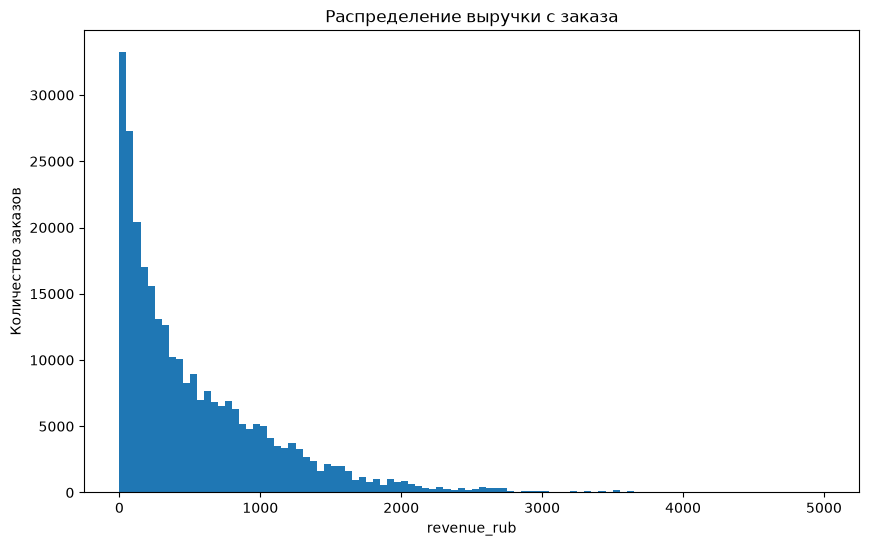

In [30]:
# Строим гистограмму выручки, ограничим ось х  5000 рублей чтобы правый хвост не съедал весь график 
df_afisha['revenue_rub'].plot(kind='hist', 
                              bins=100, 
                              range=(0, 5000), 
                              figsize=(10, 6),
                              title='Распределение выручки с заказа',
                              xlabel='revenue_rub', 
                              ylabel='Количество заказов')
plt.show()

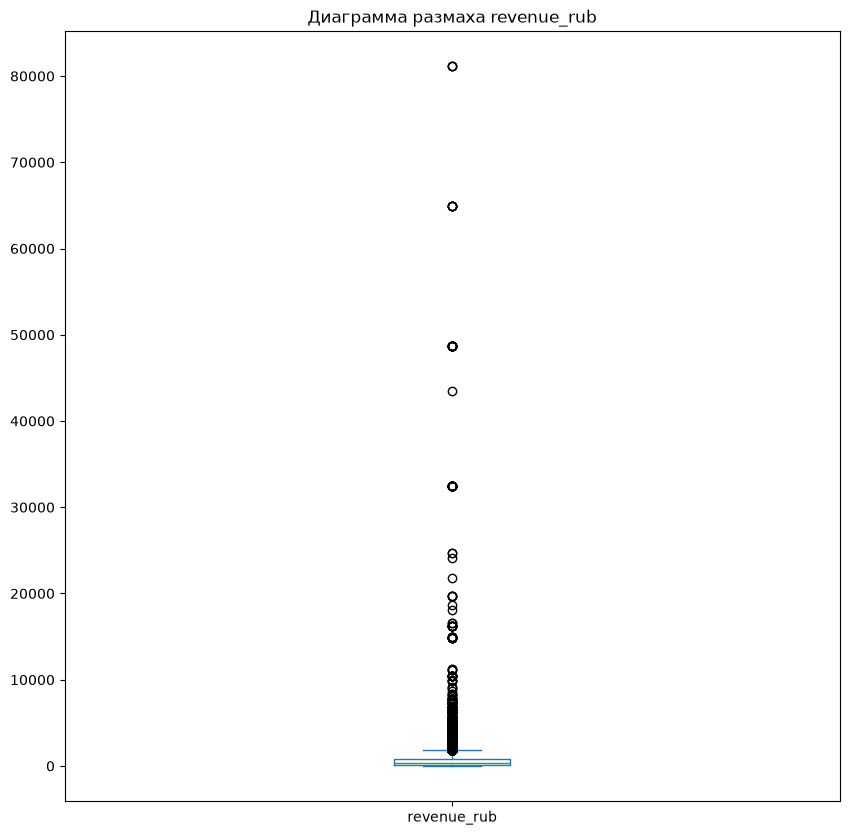

In [31]:
# Строим график размаха выручки
df_afisha['revenue_rub'].plot(kind='box', 
                              figsize=(10, 10),
                              title='Диаграмма размаха revenue_rub')
plt.show()

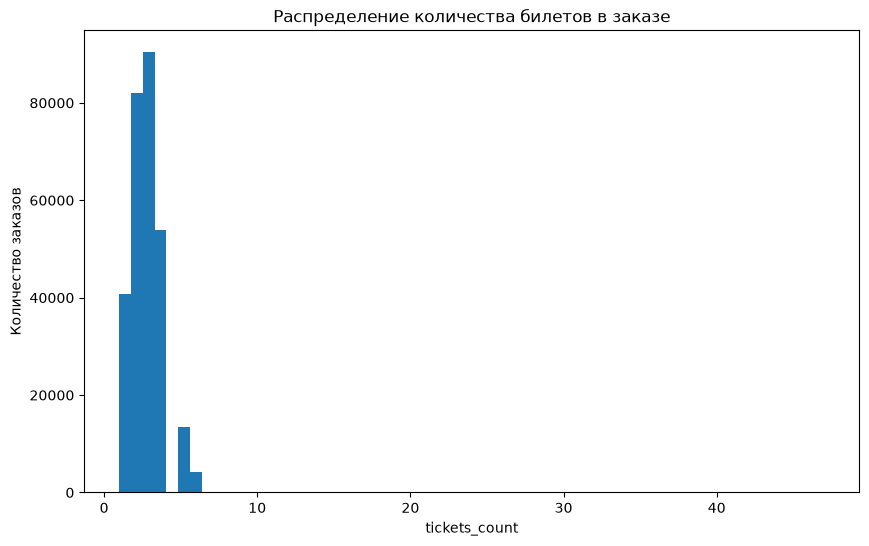

In [32]:
# Строим гистограмму количества билетов в одном заказе
df_afisha['tickets_count'].plot(kind='hist', 
                                bins=60, 
                                figsize=(10, 6),
                                title='Распределение количества билетов в заказе',
                                xlabel='tickets_count', 
                                ylabel='Количество заказов')
plt.show()

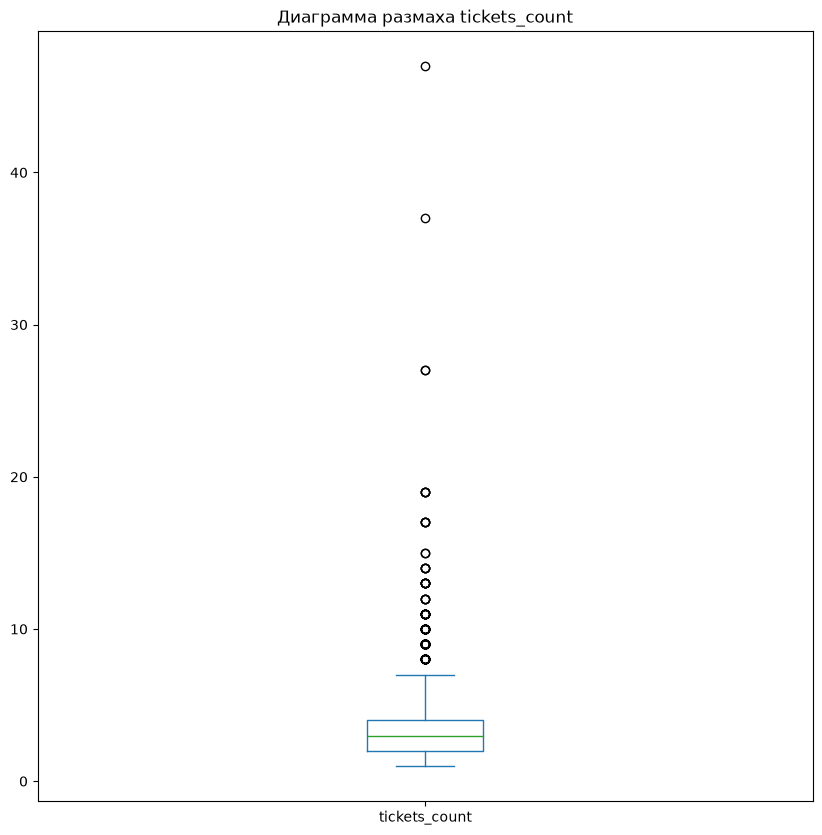

In [33]:
# Строим график размаха количества билетов
df_afisha['tickets_count'].plot(kind='box', 
                                figsize=(10, 10),
                                title='Диаграмма размаха tickets_count')
plt.show()

In [34]:
## ПЕРЕДЕЛАТЬ ПОТОМ ВСЕ ЯЧЕЙКИ ВЫШЕ ПОД print('text', var) ЧТОБЫ БЫЛО КРАСИВЕЕ

# Запоминаем размер до фильтрации выбросов
rows_before_99 = len(df_afisha)

# Считаем 99 процентиль выручки и фильтруем выбросы
percentile_99 = df_afisha['revenue_rub'].quantile(0.99)
print('99 процентиль revenue_rub:', round(percentile_99, 2))
df_afisha = df_afisha[df_afisha['revenue_rub'] <= percentile_99]

# Оцениваем объем отфильтрованных данных
print('Удалено строк:', rows_before_99 - len(df_afisha))
print('Осталось строк:', len(df_afisha))

99 процентиль revenue_rub: 2628.42
Удалено строк: 2825
Осталось строк: 281879


In [35]:
# Проверяем статистические показатели revenue_rub и tickets_count после всех фильтраций
df_afisha[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,281879.000000,281879.000000
mean,528.888313,2.744117
std,511.717247,1.157190
min,0.020000,1.000000
25%,122.690000,2.000000
50%,358.290000,3.000000
75%,798.070000,3.000000
max,2628.420000,47.000000


In [36]:
# Считаем сумму удаленных строк
del_rows_count = original_shape[0] - df_afisha.shape[0]
drc_count = round(del_rows_count / original_shape[0] * 100,2)
print("Всего удаленных строк:", original_shape[0] - df_afisha.shape[0])
print("Доля удаленных строк:", drc_count)

Всего удаленных строк: 8732
Доля удаленных строк: 3.0


#### Промежуточный вывод после предобработки данных

Выручка приведена к рублям по курсу из final_tickets_tenge_df.csv, создан столбец revenue_rub. Пропуски только в days_since_prev - первый заказ пользователя, оставили как есть. Разрядность tickets_count и days_since_prev понижена.

Удалено 5907 заказов (~2%) с нулевой и отрицательной выручкой (бесплатные мероприятия и возвраты) и 2825 строк выше 99 процентиля revenue_rub (порог 2628 руб). Всего удалено 8732 строки, ~3% данных. tickets_count не фильтровали - большие заказы могут быть связаны с покупками компаний или групп.

После предобработки: 281879 заказов, median выручки = 358 руб, среднее количество билетов ~2.7.

---
<a id='step3'></a>
### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [37]:
# Сортируем заказы по времени 
df_afisha_sorted = df_afisha.sort_values('order_ts')

In [38]:
# Строим профиль пользователя
user_profile = df_afisha_sorted.groupby('user_id').agg(
    first_order_dt = ('order_dt', 'first'),
    last_order_dt = ('order_dt', 'last'),
    first_order_device = ('device_type_canonical', 'first'),
    first_order_region = ('region_name', 'first'),
    first_order_service = ('service_name', 'first'),
    first_order_event = ('event_type_main', 'first'),
    total_orders = ('order_id', 'count'),
    avg_revenue_rub = ('revenue_rub', 'mean'),
    avg_tickets_count = ('tickets_count', 'mean'),
    avg_days_between_orders = ('days_since_prev', 'mean')
).reset_index()
# Проверяем первые строки нового датафрейма
user_profile.head()

,user_id,first_order_dt,last_order_dt,first_order_device,first_order_region,first_order_service,first_order_event,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0


In [39]:
# Добавляем бинарные признаки повторных заказов
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5

# Проверяем 
user_profile.head()

,user_id,first_order_dt,last_order_dt,first_order_device,first_order_region,first_order_service,first_order_event,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


In [40]:
# Проверяемм размер и столбцы получившегося датафрейма
user_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 21700 entries, 0 to 21699
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  21700 non-null  str           
 1   first_order_dt           21700 non-null  datetime64[us]
 2   last_order_dt            21700 non-null  datetime64[us]
 3   first_order_device       21700 non-null  str           
 4   first_order_region       21700 non-null  str           
 5   first_order_service      21700 non-null  str           
 6   first_order_event        21700 non-null  str           
 7   total_orders             21700 non-null  int64         
 8   avg_revenue_rub          21700 non-null  float64       
 9   avg_tickets_count        21700 non-null  float64       
 10  avg_days_between_orders  13457 non-null  float32       
 11  is_two                   21700 non-null  bool          
 12  is_five                  21700 non-null  bo

Создали датафрейм user_profile - размер 21700 строк, 13 столбцов. 233 пользователя отфильтровалось на предыдущих этапах.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [41]:
# Считаем основные показатели
print('Всего пользователей:', user_profile.shape[0])
print('Средняя выручка с одного заказа:', round(user_profile['avg_revenue_rub'].mean(), 2))
print('Доля пользователей с >= 2 заказами:', round(user_profile['is_two'].mean(), 2))
print('Доля пользователей с >= 5 заказами:', round(user_profile['is_five'].mean(), 2))

Всего пользователей: 21700
Средняя выручка с одного заказа: 551.88
Доля пользователей с >= 2 заказами: 0.62
Доля пользователей с >= 5 заказами: 0.29


In [42]:
# Смотрим статистику по числу заказов, билетам и интервалам между покупками
display(user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe())

# Проверяем данные total_orders и avg_tickets_count на аномалии
display(user_profile['total_orders'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1]))
display(user_profile['avg_tickets_count'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1]))

,total_orders,avg_tickets_count,avg_days_between_orders
count,21700.000000,21700.000000,13457.000000
mean,12.989816,2.746006,15.900942
std,119.766778,0.914290,22.341734
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.090909,20.500000
max,9987.000000,11.000000,148.000000


0.500       2.00
0.900      15.00
0.950      31.00
0.990     150.01
0.999    1450.01
1.000    9987.00
Name: total_orders, dtype: float64

0.500     2.75
0.900     4.00
0.950     4.00
0.990     5.00
0.999     6.00
1.000    11.00
Name: avg_tickets_count, dtype: float64

Видим что в total_orders: avg = 13, median = 2, 99 процентиль = 150, 99.9 процентиль = 1450 и max = 9987, max больше 99.9 процентиля в 60-70 раз. 
9987 заказов на одного пользователя тянет среднее к 13 в то времия как медиана - 2.  Гипотеза: Вероятно, большое количество покупок делается перекупщиками или компаниями. Такой выброс сильно исказит на анализ, отфильтруем по 99 процентилю.

Так же видим что в avg_tickets_count: avg = 2.75, median = 2.75, 99 процентиль = 5 и max = 11. Аномалий не наблюдается.

Так же видим что в avg_days_between_orders: avg = 16, median = 8, max = 148. 148 дней это почти 5 месяцев, данные у нас предоставлены за 5 месяцев, значение уместно учитывая период данных.

In [43]:
# Фильтруем аномалию в total_orders
# Сохраним оригинальное количество пользователей
users_before = len(user_profile)
# Выбираем значение 99-го процентиля
p99_orders = user_profile['total_orders'].quantile(0.99)
print('99 процентиль числа заказов:', p99_orders)

# Фильтруем пользователей выше 99 процентиля
user_profile = user_profile[user_profile['total_orders'] <= p99_orders]

# Сравниваем количество пользователей до и после фильтрации
print('Удалено пользователей:', users_before - len(user_profile))
print('Текущее число пользователей:', len(user_profile))

99 процентиль числа заказов: 150.0099999999984
Удалено пользователей: 217
Текущее число пользователей: 21483


In [44]:
# Смотрим статистические показатели после фильтрации
user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe()

,total_orders,avg_tickets_count,avg_days_between_orders
count,21483.000000,21483.000000,13240.000000
mean,6.404506,2.746183,16.153980
std,13.982574,0.918756,22.435741
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.333333
50%,2.000000,2.750000,8.394444
75%,5.000000,3.111111,21.000000
max,150.000000,11.000000,148.000000


In [45]:
# Так же пересчитаем основные показатели
print('Всего пользователей:', user_profile.shape[0])
print('Средняя выручка с одного заказа:', round(user_profile['avg_revenue_rub'].mean(), 2))
print('Доля пользователей с >= 2 заказами:', round(user_profile['is_two'].mean(), 2))
print('Доля пользователей с >= 5 заказами:', round(user_profile['is_five'].mean(), 2))

Всего пользователей: 21483
Средняя выручка с одного заказа: 552.15
Доля пользователей с >= 2 заказами: 0.61
Доля пользователей с >= 5 заказами: 0.28


Промежуточный вывод после оценки профилей:

- В выборке 21700 пользователей, средняя выручка с одного заказа = 551.88 руб. Доля вернувшихся (>=2 заказов) = 0.61, доля лояльных (>=5 заказов) = 0.28.

- В total_orders найдена аномалия: max = 9987 заказов при median = 2, max больше 99 процентиля в ~60-70 раз. Гипотеза: это перекупщики или компании. Так как это сильно искажает данные для анализа - отфильтровали по 99 процентилю (порог 150 заказов), удалено 217 пользователей (~1%), осталось 21483.

- В avg_tickets_count и avg_days_between_orders аномалий нет, оставили как есть.

- После фильтрации avg total_orders = 6.4 при median = 2 (было avg = 13) - статистика стала ближе к нормальной.

---
<a id='step4'></a>
### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [46]:
# Распределение пользователей по типу первого мероприятия
display(user_profile['first_order_event'].value_counts())
display(user_profile['first_order_event'].value_counts(normalize=True))

first_order_event
концерты    9607
другое      5223
театр       4259
стендап     1117
спорт        765
выставки     415
ёлки          97
Name: count, dtype: int64

first_order_event
концерты    0.447191
другое      0.243122
театр       0.198250
стендап     0.051995
спорт       0.035610
выставки    0.019318
ёлки        0.004515
Name: proportion, dtype: float64

In [47]:
# Распределение пользователей по устройству первой покупки
display(user_profile['first_order_device'].value_counts())
display(user_profile['first_order_device'].value_counts(normalize=True))

first_order_device
mobile     17802
desktop     3681
Name: count, dtype: int64

first_order_device
mobile     0.828655
desktop    0.171345
Name: proportion, dtype: float64

In [48]:
# Распределение пользователей по региону первого заказа
# Регионов много, выведем топ-10
display(user_profile['first_order_region'].value_counts().head(10))
display(user_profile['first_order_region'].value_counts(normalize=True).head(10))

first_order_region
Каменевский регион      6973
Североярская область    3783
Широковская область     1234
Озернинский край         678
Малиновоярский округ     527
Шанырский регион         465
Травяная область         461
Светополянский округ     461
Речиновская область      445
Яблоневская область      411
Name: count, dtype: int64

first_order_region
Каменевский регион      0.324582
Североярская область    0.176093
Широковская область     0.057441
Озернинский край        0.031560
Малиновоярский округ    0.024531
Шанырский регион        0.021645
Травяная область        0.021459
Светополянский округ    0.021459
Речиновская область     0.020714
Яблоневская область     0.019131
Name: proportion, dtype: float64

In [49]:
# Распределение пользователей по билетному оператору первого заказа
# Операторов много, выведем топ-10
display(user_profile['first_order_service'].value_counts().head(10))
display(user_profile['first_order_service'].value_counts(normalize=True).head(10))

first_order_service
Билеты без проблем    4968
Мой билет             2996
Лови билет!           2801
Билеты в руки         2548
Облачко               2196
Весь в билетах        1291
Лучшие билеты         1183
Прачечная              586
Край билетов           460
Дом культуры           358
Name: count, dtype: int64

first_order_service
Билеты без проблем    0.231253
Мой билет             0.139459
Лови билет!           0.130382
Билеты в руки         0.118605
Облачко               0.102220
Весь в билетах        0.060094
Лучшие билеты         0.055067
Прачечная             0.027277
Край билетов          0.021412
Дом культуры          0.016664
Name: proportion, dtype: float64

Промежуточный вывод по распределению пользователей

- Пользователи распределены по сегментам неравномерно, во всех есть выраженные точки входа:

    - по типу мероприятия: концерты - 44.7%, другое - 24.3%, театр - 19.8%. ~89% пользователей сконцентрированны в топ-3 типах мероприятий;
    - по устройству: mobile - 82.9%, desktop - 17.1%;
    - по региону: Каменевский регион - 32.5%, Североярская область - 17.6%, остальные регионы меньше 6% каждый. Топ-2 региона держат ~51% пользователей;
    - по оператору: "Билеты без проблем" - 23.1%, "Мой билет", "Лови билет!", "Билеты в руки" и "Облачко" по 10-14%. ~72% сконцентрированно в топ-5 операторах.

Главные выраженнные точки входа: тип: концерты, устройство: mobile, регионы: Каменевский регион и Сeвероярская область, операторы: Билеты без проблем(23.1%), но концентрация по операторам ниже других признаков, есть выраженный топ-5 = ~72%.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Чтобы выполнить задачу по нахождению сегмента, где пользователи чаще совершают повторный заказ - нам сначала нужно определить среднюю долю вернувшихся из всех данных, чтобы было с чем сравнивать сегменты.

In [50]:
# Считаем среднюю долю is_two по всей выборке
is_two_ratio_all = user_profile['is_two'].mean()
print('Доля вернувшихся в среднем по выборке:', round(is_two_ratio_all, 3))

Доля вернувшихся в среднем по выборке: 0.613


In [51]:
# Считаем возвраты по сегменту типа мероприятий
events_return = user_profile.groupby('first_order_event').agg(
    user_count = ('user_id', 'count'),
    is_two_ratio = ('is_two', 'mean')
).sort_values('user_count', ascending=False)
display(events_return)

,user_count,is_two_ratio
first_order_event,,
концерты,9607,0.617779
другое,5223,0.594294
театр,4259,0.634891
стендап,1117,0.608774
спорт,765,0.549020
выставки,415,0.643373
ёлки,97,0.567010


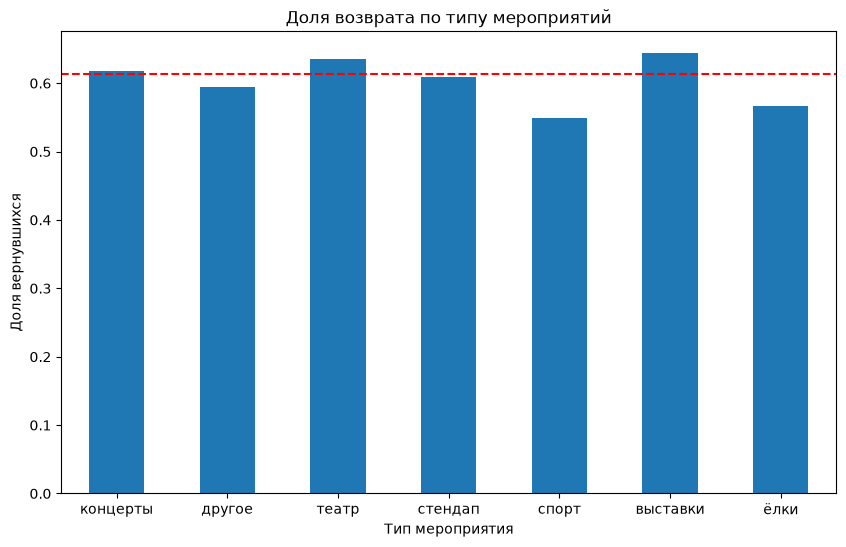

In [52]:
# Строим столбцовый график
events_return['is_two_ratio'].plot(kind='bar',
                                   rot=0,
                                   figsize=(10,6),
                                   title='Доля возврата по типу мероприятий',
                                   xlabel='Тип мероприятия',
                                   ylabel='Доля вернувшихся'
                                  )
plt.axhline(is_two_ratio_all, color='red', linestyle='--', label='средняя доля по всей выборке')

In [53]:
# Считаем возвраты по сегменту тип девайса
device_returns = user_profile.groupby('first_order_device').agg(
    user_count = ('user_id','count'),
    is_two_ratio = ('is_two','mean')
).sort_values('user_count', ascending=False)
device_returns

,user_count,is_two_ratio
first_order_device,,
mobile,17802,0.608078
desktop,3681,0.635697


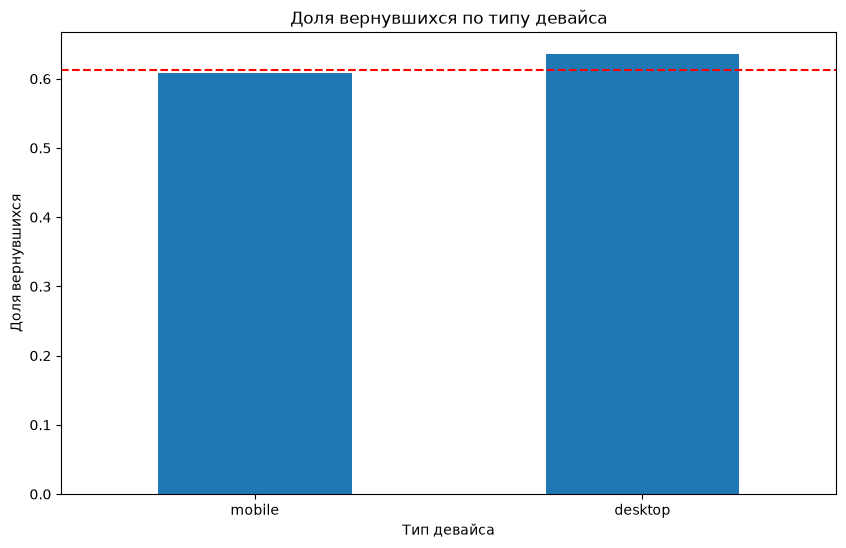

In [54]:
# Строим столбчатый график
device_returns['is_two_ratio'].plot(kind='bar',
                    figsize=(10,6),
                    rot=0,
                    title='Доля вернувшихся по типу девайса',
                    xlabel='Тип девайса',
                    ylabel='Доля вернувшихся'
                                   )
plt.axhline(is_two_ratio_all, color='red', linestyle='--', label='средняя доля по всей выборке')

In [55]:
# Считаем возвраты по сегменту регион ( по заданию оставляем топ-10 регионов)
region_returns = user_profile.groupby('first_order_region').agg(
    user_count = ('user_id','count'),
    is_two_ratio = ('is_two','mean')
).sort_values('user_count', ascending=False).head(10)
region_returns

,user_count,is_two_ratio
first_order_region,,
Каменевский регион,6973,0.619102
Североярская область,3783,0.640497
Широковская область,1234,0.645057
Озернинский край,678,0.551622
Малиновоярский округ,527,0.557875
Шанырский регион,465,0.694624
Светополянский округ,461,0.657267
Травяная область,461,0.616052
Речиновская область,445,0.638202


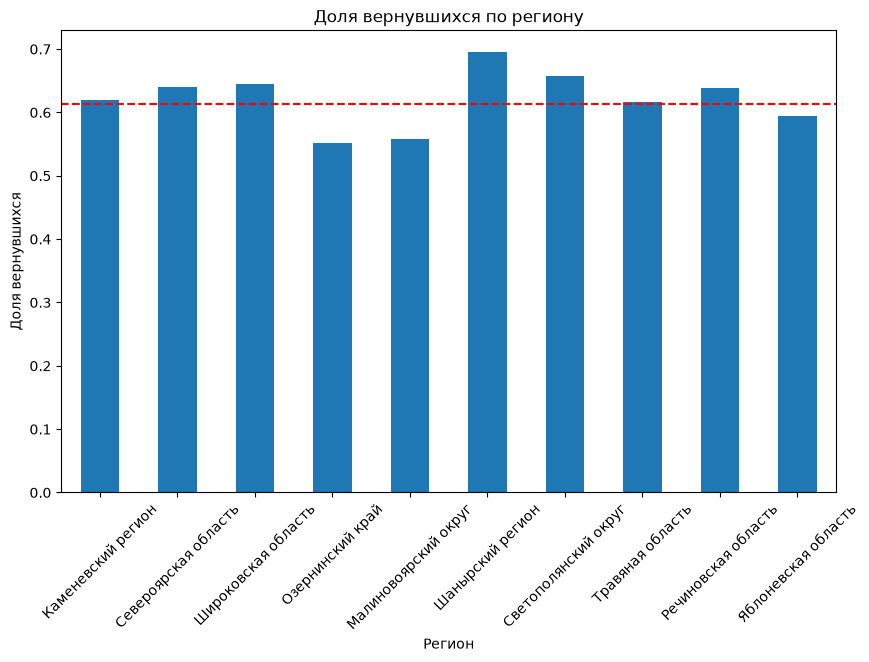

In [56]:
# Строим столбчатый график
region_returns['is_two_ratio'].plot(kind='bar',
                    rot=45,
                    figsize=(10,6),
                    title='Доля вернувшихся по региону',
                    xlabel='Регион',
                    ylabel='Доля вернувшихся')
plt.axhline(is_two_ratio_all, color='red', linestyle='--', label='средняя доля по всей выборке')

In [57]:
# Считаем вернувшихся по сегменту Оператора (по заданию берем топ-10 )
service_returns = user_profile.groupby('first_order_service').agg(
    user_count=('user_id','count'),
    is_two_ratio=('is_two','mean')
).sort_values('user_count', ascending=False).head(10)
service_returns

,user_count,is_two_ratio
first_order_service,,
Билеты без проблем,4968,0.597625
Мой билет,2996,0.607810
Лови билет!,2801,0.611210
Билеты в руки,2548,0.629513
Облачко,2196,0.613388
Весь в билетах,1291,0.628970
Лучшие билеты,1183,0.614539
Прачечная,586,0.626280
Край билетов,460,0.654348


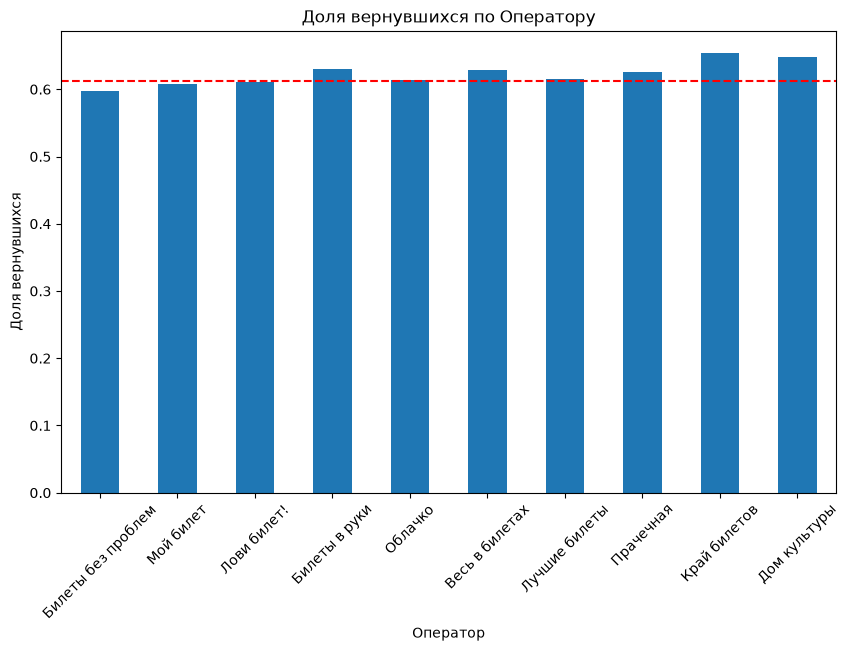

In [58]:
# Строим столбчатый график
service_returns['is_two_ratio'].plot(kind='bar',
                     rot=45,
                     figsize=(10,6),
                     title='Доля вернувшихся по Оператору',
                     xlabel='Оператор',
                     ylabel='Доля вернувшихся')
plt.axhline(is_two_ratio_all, color='red', linestyle='--', label='средняя доля по всей выборке')

Промежуточный вывод после анализа возврата пользователей:
Средняя доля вернувшихся по выборке = 0.616. Из анализа сегментов и графиков видим что разброс между сегментами находится в пределах ~ 0.55-0.70.

- по типу мероприятия: чаще возвращаются выставки (0.64) и театр (0.635), реже всех - спорт (0.549) и ёлки (0.567). Концерты (0.618) на уровне средней доли по всей выборке;
- по типу устройства: desktop (0.635) немного выше mobile (0.608);
- по региону: лидер Шанырский регион (0.695), при этом в этом регионе всего 465 пользователей - результат анализаз может быть не достоверным. В крупнейших регионах по количеству пользователей (Каменевский 6973 пользователей, Североярская 3783 пользователей) доля возврата на уровне средней по всей выборке. Ниже средней находятся Озернинский край (0.55) и Малиновоярский округ (0.56);
- по оператору: Край билетов (0.655) и Дом культуры (0.65) находятся в топе, но при этом имеют всего 460 и 358 пользователей - анализ может быть недостоверным. Крупнейшие операторы по кооличеству пользователей - Билеты без проблем 4868 (0.597) и Мой билет 2996 (0.608) из топ-10 ниже средней доли по всей выборке.

Успешные точки входа есть: выше средней доли возврата (0.616) возвращаются
по типу мероприятия - театр (0.635), по типу устройства - desktop (0.635) и по регионам - Североярская область (~0.64) - это крупные сегменты, их долям можно доверять.
Так же есть регионы вроде Шанырского региона (0.695, всего 465 пользователей) - данные могут быть недостоверны, а крупнейшие сегменты определенные на прошлом этапе (концерты, mobile, Билеты без проблем) все находятся на уровне средней или ниже.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Используем данными и рассчетами из прошлых этапов для проверки гипотез 1 и 2

In [59]:
# Гипотеза 1: 
# Сравниваем долю возврата у спорта и концертов.
# *используем loc так как значения из столбца first_order_event стали индексами после группировки
print('Доля вернувшихся - спорт:', round(events_return.loc['спорт', 'is_two_ratio'], 3))
print('Доля вернувшихся - концерты:', round(events_return.loc['концерты', 'is_two_ratio'], 3))
print('Средняя по выборке:', round(is_two_ratio_all, 3))

Доля вернувшихся - спорт: 0.549
Доля вернувшихся - концерты: 0.618
Средняя по выборке: 0.613


Гипотеза 1 не подтверждается: видим что спорт (0.549) возвращается реже концертов (0.618) и из рассчетов прошлого этапа видно что спорт возвращается реже всех остальных типов мероприятий. У типа спорт всего 765 пользователей, выборка небольшая, но разрыв в долях достаточно ощутимый для опровержения гипотезы.

Для анализа гипотезы 2 возьмем цифры из топ-10 регионов и разделим все регионы на две группы: >1000 и <1000. Регионы разделяться на топ-3 в первой группе и все остальные регионы во второй группе.

In [60]:
# Гипотеза 2: сравниваем возврат в топ-3 и остальных регионах
# Из region_returns берем топ-3 региона
top3_regions = ['Каменевский регион', 'Североярская область', 'Широковская область']

# Выделяем пользователей из топ-3 регионов
top_users = user_profile[user_profile['first_order_region'].isin(top3_regions)]
# Выделяем пользователей из остальных регионов
other_users = user_profile[~user_profile['first_order_region'].isin(top3_regions)]
print('Пользователей в топ-3 регионах:', len(top_users))
print('Доля вернувшихся в топ-3 регионах:', round(top_users['is_two'].mean(), 3))
print('Пользователей в остальных регионах:', len(other_users))
print('Доля вернувшихся в остальных регионах:', round(other_users['is_two'].mean(), 3))

Пользователей в топ-3 регионах: 11990
Доля вернувшихся в топ-3 регионах: 0.629
Пользователей в остальных регионах: 9493
Доля вернувшихся в остальных регионах: 0.593


Из рассчетов видим: Гипотеза 2 подтверждается: в топ-3 регионах доля вернувшихся 0.629, в остальных 0.593. Разница ~0.036, учитывая что выборка в обеих группах в районе 10000 - разрыв ощутим и подкреплен объемом данных. Уточнение: Из прошлого этапа можем увидеть что разброс долей возврата во второй группе регионов довольно высокий (например, Шанырский регион - самый высокий по возврату 0.695). Это может указывать на то, что правилом зависимость возврата от активности региона назвать нельзя, скорее слабой зависимостью

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [61]:
# Делим пользователей на две группы: один заказ и вернувшиеся
not_returned_users = user_profile[user_profile['is_two'] == False]
returned_users = user_profile[user_profile['is_two'] == True]

print('Пользователей с одним заказом:', len(not_returned_users))
print('Вернувшихся пользователей:', len(returned_users))

Пользователей с одним заказом: 8318
Вернувшихся пользователей: 13165


Графики будем делать наложением друг на друга для сравнения.

Text(0, 0.5, 'Плотность')

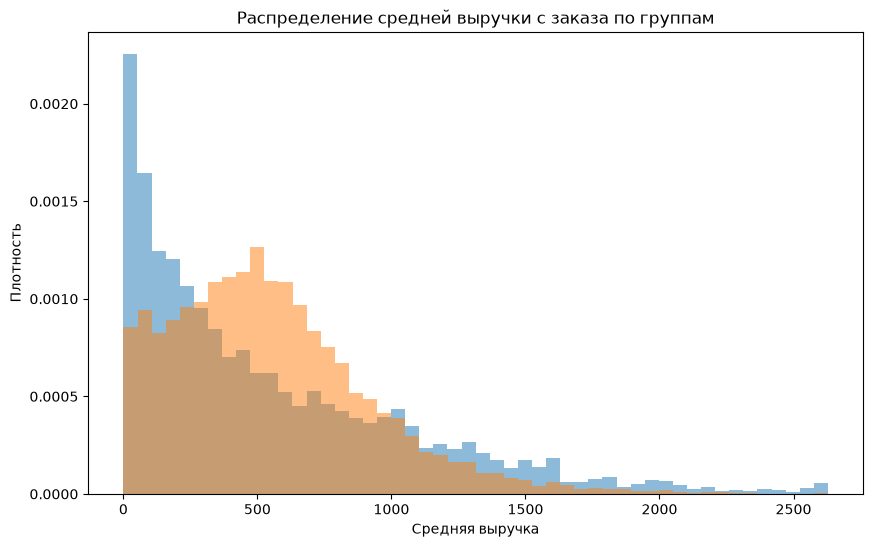

In [62]:
# Сначала создадим оси для графиков 
fig, ax = plt.subplots(figsize=(10, 6))

# Строим  на соозданных осях сравнительные гистограммы средней выручки с заказа
not_returned_users['avg_revenue_rub'].plot(kind='hist',
                                        bins=50,
                                        alpha=0.5,
                                        density=True,
                                        ax=ax,
                                        label='1 заказ')
returned_users['avg_revenue_rub'].plot(kind='hist',
                                       bins=50,
                                       alpha=0.5,
                                       density=True,
                                       ax=ax,
                                       label='2 и более заказов')
ax.set_title('Распределение средней выручки с заказа по группам')
ax.set_xlabel('Средняя выручка')
ax.set_ylabel('Плотность')

Из графика видим что группа невернувшихся концентрируется в основном в самых дешевых заказах (до ~150 рублей), а группа вернувшихся - в заказах со средней стоимости (~400-700 рублей).
У группы вернувшихся провал в самых дешевых заказах, там где у невернувшихся - пик - вероятно покупки с низкой стоимостью это маркер невозврата?

Так же видим правый хвост у обеих групп, у группы невернувшихся зачений в правой стороне графика больше.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [63]:
# Делим пользователей на две группы: 2-4 заказа и 5 и больше заказов
# для группы 2-4 заказа вычтем группу 5 и больше чтобы не дублировались данные
returned_2_users = user_profile[(user_profile['is_two'] == True) & (user_profile['is_five'] == False)]
returned_5_users = user_profile[user_profile['is_five'] == True]

print('Пользователей с 2-4 заказами:', len(returned_2_users))
print('Пользователей с >=5 заказами:', len(returned_5_users))

Пользователей с 2-4 заказами: 7118
Пользователей с >=5 заказами: 6047


Text(0, 0.5, 'Плотность')

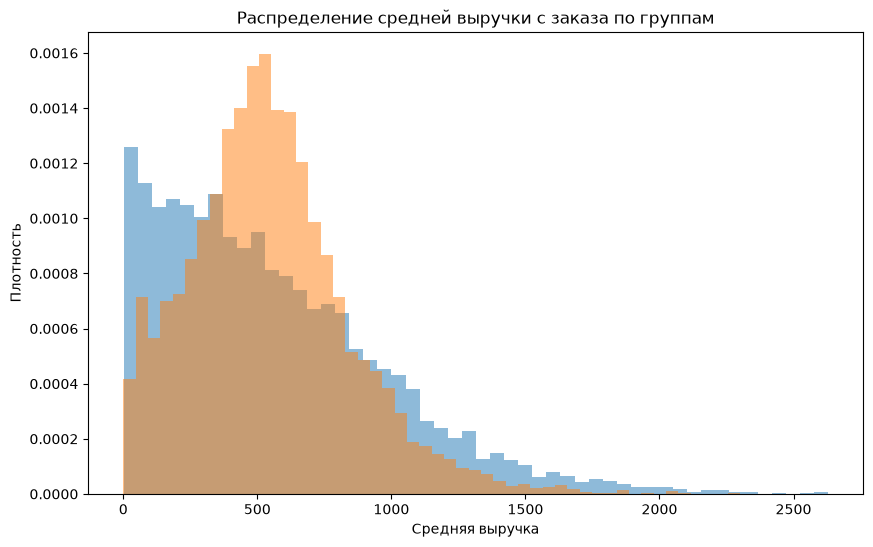

In [64]:
# Сначала создадим оси для графиков 
fig, ax = plt.subplots(figsize=(10, 6))

# Строим  на соозданных осях сравнительные гистограммы средней выручки с заказа
returned_2_users['avg_revenue_rub'].plot(kind='hist',
                                        bins=50,
                                        alpha=0.5,
                                        density=True,
                                        ax=ax,
                                        )
returned_5_users['avg_revenue_rub'].plot(kind='hist',
                                       bins=50,
                                       alpha=0.5,
                                       density=True,
                                       ax=ax,
                                       )
ax.set_title('Распределение средней выручки с заказа по группам')
ax.set_xlabel('Средняя выручка')
ax.set_ylabel('Плотность')

Из графика видим что группа 2-4 заказа имеет большую плотность в дешевых заказах (от 0 до ~350 рублей). А группа >=5 заказов концентрируется в заказах средней стоимости (~400-700 рублей) с выраженным пиком в районе ~600-700 рублей.

У группы >=5 дешевых заказов заметно меньше, чем у группы 2-4 - схоже с результатом из прошлой задачи: чем больше заказов у пользователя, тем меньше в его профиле дешевых покупок.

Правый хвост обеих групп похож, у группы 2-4 значений там даже немного больше.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

<Axes: title={'center': 'Распределение по среднему числу билетов'}, xlabel='Среднее число билетов', ylabel='Число пользователей'>

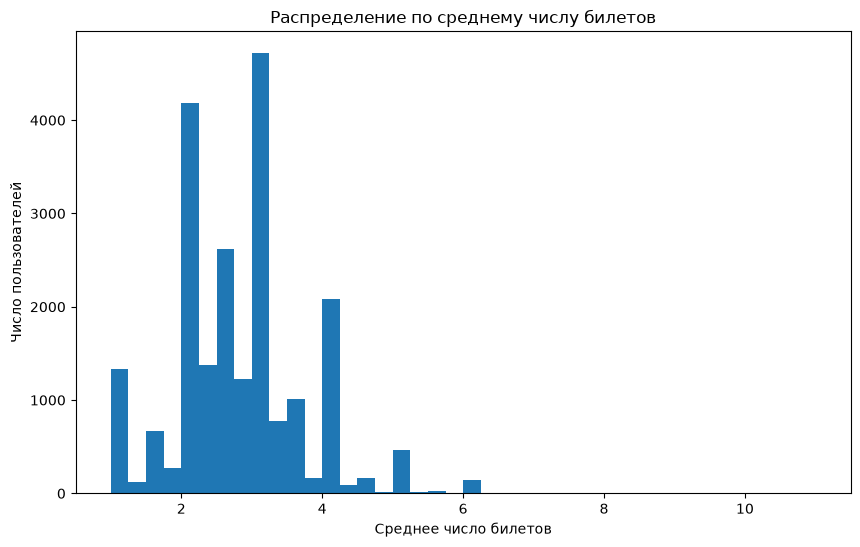

In [65]:
# Смотрим распределение пользователей по среднему числу билетов
user_profile['avg_tickets_count'].plot(kind='hist',
                                       bins=40,
                                       figsize=(10, 6),
                                       title='Распределение по среднему числу билетов',
                                      xlabel='Среднее число билетов',
                                      ylabel='Число пользователей')

In [66]:
# Разделим пользователей на сегменты по заданию используя метод .cut()
user_profile['tickets_segment'] = pd.cut(user_profile['avg_tickets_count'],
                                         bins=[1, 2, 3, 5, 11],
                                         labels=['1-2', '2-3', '3-5', '>5'],
                                         include_lowest=True)
# Проверяем результат
user_profile['tickets_segment'].value_counts()

tickets_segment
2-3    9833
1-2    6109
3-5    5347
>5      194
Name: count, dtype: int64

In [67]:
# Считаем число пользователей и долю вернувшихся в каждом сегменте
tickets_returns = user_profile.groupby('tickets_segment').agg(
    user_count=('user_id', 'count'),
    is_two_ratio=('is_two', 'mean')
)
tickets_returns

,user_count,is_two_ratio
tickets_segment,,
1-2,6109,0.400229
2-3,9833,0.742195
3-5,5347,0.628203
>5,194,0.324742


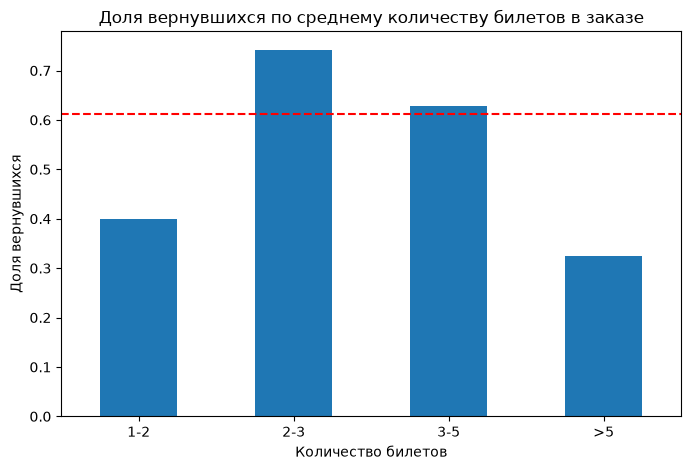

In [68]:
# Строим столбчатый график доли вернувшихся по сегментам и сравниваем c средним по всей выборке как в прошлых этапах
tickets_returns['is_two_ratio'].plot(kind='bar',
                                     rot=0,
                                     figsize=(8, 5),
                                     title='Доля вернувшихся по среднему количеству билетов в заказе',
                                     xlabel='Количество билетов',
                                     ylabel='Доля вернувшихся')
plt.axhline(is_two_ratio_all, color='red', linestyle='--', label='средняя доля по всей выборке')

Видим что пользователи распределены неравномерно, сконцентрировано: больше всего в сегменте 2-3 билета (9833), сегменты 1-2 и 3-5 примерно равны (6109 и 5347) и сегмент >5 ощутимо меньше всех остальных - 194 пользователя.

Аномалии есть: сегмент 2-3 билета возвращается сильно выше средней доли по всей выборке(0.742 при средней 0.616), а сегмент 1-2 - сильно ниже (0.4). У сегмента >5 самый низкий возврат - 0.325, но пользователей там мало, рассчет доли малонадежный.

Разброс между сегментами самый большой среди всех признаков в проекте - видим что количество билетов в заказе связано с возвратом сильнее чем тип мероприятия, регион или устройство.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Для задачи сегментируем пользователей по дням недели используя аксессор .dt с атрибутом dayofweek

In [69]:
# Сегментируем пользователей по дню недели
user_profile['first_order_dayofweek'] = user_profile['first_order_dt'].dt.dayofweek

# Проверяем результат
user_profile['first_order_dayofweek'].value_counts()

first_order_dayofweek
5    3292
4    3230
1    3157
3    3098
2    3048
0    2901
6    2757
Name: count, dtype: int64

In [70]:
# Считаем число пользователей и долю вернувшихся по дням недели
dayofweek_returns = user_profile.groupby('first_order_dayofweek').agg(
    user_count=('user_id', 'count'),
    is_two_ratio=('is_two', 'mean')
)
dayofweek_returns

,user_count,is_two_ratio
first_order_dayofweek,,
0,2901,0.626336
1,3157,0.617358
2,3048,0.621719
3,3098,0.594900
4,3230,0.599071
5,3292,0.627886
6,2757,0.601741


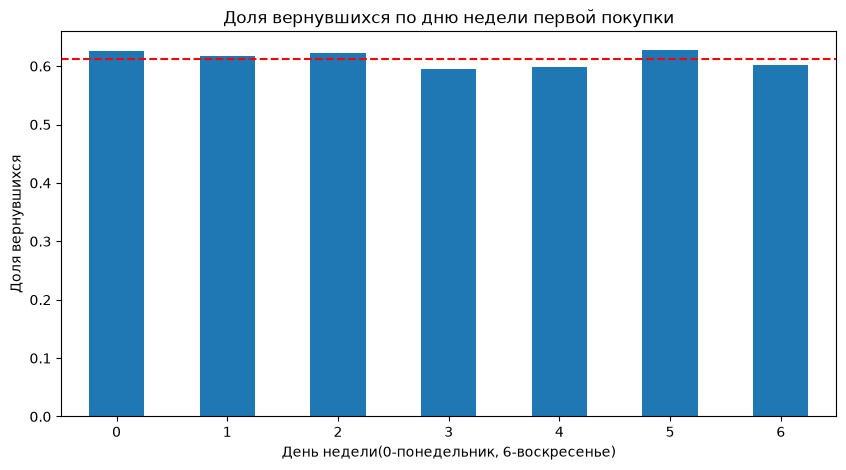

In [71]:
# Строим график доли вернувшихся по дням недели и сравниваем со средней долей по всей выборке
dayofweek_returns['is_two_ratio'].plot(kind='bar',
                                     rot=0,
                                     figsize=(10, 5),
                                     title='Доля вернувшихся по дню недели первой покупки',
                                     xlabel='День недели(0-понедельник, 6-воскресенье)',
                                     ylabel='Доля вернувшихся')
plt.axhline(is_two_ratio_all, color='red', linestyle='--', label='средняя доля по всей выборке')

Видим что пользователи по дням недели распределены равномерно (от 2757 до 3292 человек). Доля вернувшихся по всем дням лежит в пределах 0.595-0.628, средняя доля по всей выборке 0.616, размах минимальный - 0.03.

День недели первой покупки на вероятность возврата не влияет.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Для рассчетов используем созданные срезы из прошлых этапов returned_2_users и returned_5_users, и столбец avg_days_between_orders. Так же высчитаем медиану чтобы учесть влияние выбросов на среднее. Добавим визуализацию для лучшего понимания результатов.

In [72]:
# Сравниваем средний интервал между заказами у групп 2-4 и 5+
print('Средний интервал, 2-4 заказа:', round(returned_2_users['avg_days_between_orders'].mean(), 2))
print('Средний интервал, >5 заказов:', round(returned_5_users['avg_days_between_orders'].mean(), 2))
print('Медианный интервал, 2-4 заказа:', round(returned_2_users['avg_days_between_orders'].median(), 2))
print('Медианный интервал, >5 заказов:', round(returned_5_users['avg_days_between_orders'].median(), 2))

Средний интервал, 2-4 заказа: 21.22
Средний интервал, >5 заказов: 9.89
Медианный интервал, 2-4 заказа: 9.0
Медианный интервал, >5 заказов: 8.11


<Axes: title={'center': 'Распределение среднего интервала между заказами'}, xlabel='Средний интервал между заказами, дней', ylabel='Плотность'>

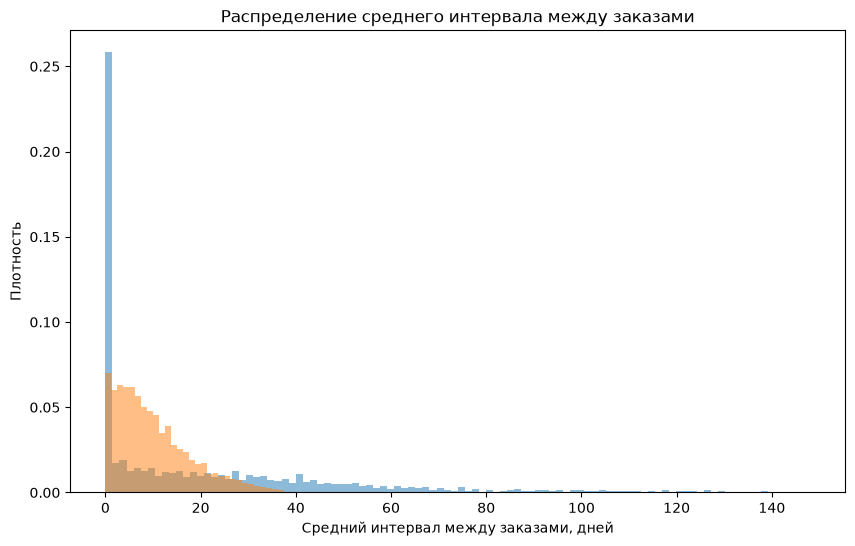

In [73]:
# Строим сравнительные гистограммы интервалов между заказами
fig, ax = plt.subplots(figsize=(10, 6))
returned_2_users['avg_days_between_orders'].plot(kind='hist',
                                                 bins=100,
                                                 alpha=0.5,
                                                 density=True,
                                                 ax=ax,
                                                 label='2-4 заказа')
returned_5_users['avg_days_between_orders'].plot(kind='hist',
                                                 bins=30,
                                                 alpha=0.5,
                                                 density=True,
                                                 ax=ax,
                                                 label='5 и более заказов',
                                                 title='Распределение среднего интервала между заказами',
                                                 xlabel='Средний интервал между заказами, дней',
                                                 ylabel='Плотность')

Из рассчетов и графика видим, что средний интервал у группы 2-4 = 21.2 дня, у группы 5+ = 9.9 дня, разница в ~2 раза. При этом видим что медианы почти очень близки: 9.0 и 8.1 дня. Это показывает что в среднем пользователь из обеих групп возвращается через ~8-9 дней, а разница в средних значениях связана с выбросом в группе 2-4 (40-140 дней между заказами), на графике видим длинный правый хвост.

Анализ показывает что чаще всего лояльные пользователи возвращаются в течении первых двух недель, если этот период истекает - шанс на возврат сильно снижается.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

По рекомендации из задания будем использовать interval_cols(зададим их в переменной).
Так же, для анализа не будем использовать is_two, is_five и tickets_segment так как это будет повторением данных(столбцы выведены из total_orders и avg_tickets_count)

In [74]:
# Выбираем столбцы для анализа и сохраняем в переменную
corr_cols = ['first_order_device', 'first_order_region', 'first_order_service',
             'first_order_event', 'first_order_dayofweek', 'avg_revenue_rub',
             'avg_tickets_count', 'avg_days_between_orders', 'total_orders']

# Выбираем интервальные столбцы и сохраняем в переменную
interval_cols = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between_orders', 'total_orders']

# Считаем phi_k используя созаднные списки и выводим интересующий нас столбец total_orders
phik_matrix = user_profile[corr_cols].phik_matrix(interval_cols=interval_cols)
round(phik_matrix['total_orders'].sort_values(ascending=False),3)

total_orders               1.000
avg_days_between_orders    0.295
avg_tickets_count          0.231
avg_revenue_rub            0.226
first_order_region         0.125
first_order_dayofweek      0.053
first_order_service        0.031
first_order_event          0.029
first_order_device         0.016
Name: total_orders, dtype: float64

In [75]:
# Проверяем разброс данных в total_orders
display(user_profile['total_orders'].describe())
display(user_profile['total_orders'].value_counts().head(10))

count    21483.000000
mean         6.404506
std         13.982574
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        150.000000
Name: total_orders, dtype: float64

total_orders
1     8318
2     3556
3     2170
4     1392
5      966
6      696
7      533
8      454
9      379
10     286
Name: count, dtype: int64

Видим что корреляция phi_k признаков из профиля пользователя не нулевые, но и не высокие (max=0.295). Из анализа статистических показателей total_orders видим, что большинство заказов(>~50%) сконцентрированно в пределах 1-2 заказов.

В соответствии с заданием выделим сегменты по полю total_orders и повторим рассчет phi_k

In [76]:
# Выделяем сегменты по числу заказов(развернем скобки right=False чтобы создать группы 1, 2-4,5)
user_profile['orders_segment'] = pd.cut(user_profile['total_orders'],
                                        bins=[1, 2, 5, 151],
                                        labels=['1', '2-4', '>5'],
                                        right=False)

# Проверяем
user_profile['orders_segment'].value_counts()

orders_segment
1      8318
2-4    7118
>5     6047
Name: count, dtype: int64

In [77]:
# Отбираем новый признаки, вместо total_orders берем сегменты по числу заказов(убираем total_orders)
corr_cols_new = ['first_order_device', 'first_order_region', 'first_order_service',
                 'first_order_event', 'first_order_dayofweek', 'avg_revenue_rub',
                 'avg_tickets_count', 'avg_days_between_orders', 'orders_segment']

# Отбираем новые интервальные столбцы(убираем total_orders) 
interval_cols_new = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between_orders']

# Считаем матрицу корреляции phi_k по сегментам
phik_matrix_new = user_profile[corr_cols_new].phik_matrix(interval_cols=interval_cols_new)
round(phik_matrix_new['orders_segment'].sort_values(ascending=False),3)

orders_segment             1.000
avg_days_between_orders    0.396
avg_tickets_count          0.383
avg_revenue_rub            0.326
first_order_region         0.127
first_order_service        0.083
first_order_event          0.044
first_order_dayofweek      0.031
first_order_device         0.016
Name: orders_segment, dtype: float64

Text(0.5, 1.0, 'Матрица корреляции phi_k (сегменты по числу заказов)')

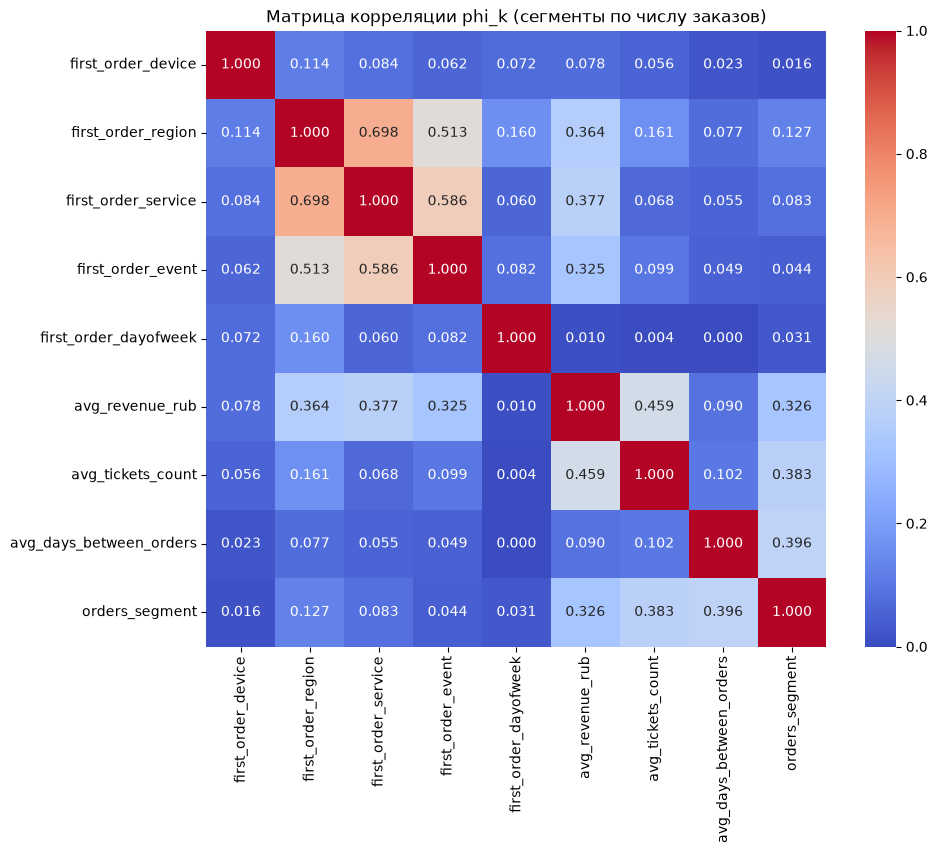

In [78]:
# Строим тепловую карту корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix_new, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Матрица корреляции phi_k (сегменты по числу заказов)')

Видим что рекомендация из задания по сегментации показывает более сильные связи. avg_days_between_orders выросла с 0.295 до 0.396, avg_tickets_count с 0.231 до 0.383, avg_revenue_rub с 0.226 до 0.326.

С количеством заказов больше всего связаны:
- временной интервал между заказами avg_days_between_orders (0.396)
- количество билетов avg_tickets_count (0.383)
- средня выручка avg_revenue_rub (0.325)

Характеристики первого заказа связаны гораздо слабее: регион (0.127), остальные ниже 0.1.

Так же видим что характеристики первого заказа сильно связаны между собой - это логично, так как определенные оператора работают в определенных регионах, тоже самое касается и типа мероприятий. Так же - выручка и количество билетов связаны, что тоже логично - больше билетов - выше стоимость.

<a id='step5'></a>
### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Общий вывод

Данные и подготовка

Работали с выгрузкой заказов Яндекс Афиши за 5 месяцев 2024 года. Выручку в тенге перевели в рубли по курсу из отдельного датасета (столбец revenue_rub). Удалили 5907 заказов (~2%) с нулевой и отрицательной выручкой - вероятно это бесплатные мероприятия и возвраты, искажающие анализ. Отфильтровали выбросы выручки по 99 процентилю, всего убрали ~3% данных. После фильтрации построили профиль пользователя. В профилях отфильтровали выбросы в количестве заказов (так какбыли пользователи с 9987 заказами - вероятно перекупщики или компании) по 99 процентилю, убрали ~1% пользователей.

Основные результаты

В итоговой выборке 21483 пользователя. Распределение по числу заказов сильно скошено: медиана - 2 заказа, 55% пользователей имеют 1-2 заказа, при этом есть длинный хвост до 150 заказов. Доля вернувшихся пользователей (>=2 заказа) = 0.616, доля лояльных пользователей (>=5) = 0.28.

Характеристики первого заказа слабо влияют на возврат. Разброс доли возврата между сегментами по типу мероприятия, устройству и региону небольшой (0.09-0.14). Первая гипоетза из задания не подтвердилась: спорт возвращается не чаще, а реже концертов (0.549 против 0.618); Гипотеза 2 подтвердилась только частично, так как активные регионы дают лишь небольшое преимущество (0.629 против 0.593), но это нельзя назвать правилом - лучший регино по возврату - мелкий регион по количеству людей.

Выручка и количество билетов связаны с возвратом сильнее. Дешевый первый заказ - показатель невозврата: пользователи с одним заказом концентрируются в заказах до ~150 руб, вернувшиеся - в среднем чеке ~400-700 руб. Самый сильный признак во всем проекте - среднее количество билетов: сегмент 2-3 билета возвращается на 0.742, а 1-2 билета всего на 0.400.

Временные характеристики: день недели первой покупки на возврат не влияет (все дни недели находятся в пределах 0.595-0.628). Важна скорость возврата - лояльные пользователи возвращаются быстро, в среднем в течении ~8-9 дней.

Корреляционный анализ phi_k так же подтверждает: с числом заказов больше всего связаны такие харектеристики: интервал между заказами 0.396, количество билетов 0.383, выручка 0.326, а характеристики первого заказа - связаны очень слабо (регион 0.127, остальные ниже 0.1).

Рекомендации
Приоритетный сегмент для удержания - пользователи с первым заказом на 2-3 билета в среднем чеке (~400-700 руб). Они возвращаются чаще всех (0.742). На них стоит настраивать программы лояльности и персональные предложения в первую очередь.

Так же можно выделить дополнительные усилия на пользователей с одиночным дешевым первым заказом (1-2 билета, до ~150 руб), так как это большой сегмент с низким возвратом (0.400). Стоит попытаться завлечь их для второго заказа (вероянто с помощью специальных предложений после первой покупки).
Анализ показал что дейстовать нужно быстро. Лояльные пользователи чаще всего возвращаются в первые 1-2 недели, можно сделать вывод что если пользователь не сделает второй заказ за ~2 недели, вероятность что он станет постоянным клиентом падает - усилия по завлечению и усилению лояльности стоит проводить в этот период.

Тип мероприятия, регион, устройство и день недели первой покупки почти не связаны с возвратом, не стоит фокусироваться на этих характеристиках.

<a id='step6'></a>
### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
https://github.com/wikbon/yp_ds_m2_final_project_afisha